# Wet days y precipitación media: CR2MET vs ALADIN (dominio común)

Comparación en el periodo histórico **1980-2014** con wet day **pr ≥ 1 mm/día**.

**Dominio espacial común** (números consolidados y mapas):
- Máscara: **Chile continental** (Natural Earth `admin_0_countries`, resolución 10m).
- Grilla de referencia: **ALADIN CHP12** (`y` × `x`, coordenadas `lat`/`lon` 2D).
- **CR2MET** se interpola linealmente a esa grilla (`scipy` vía `xarray.interp`).
- **ALADIN** permanece en su grilla nativa; ambos se enmascaran con el mismo polígono.

La primera celda de código imprime el registro del dominio (celdas válidas, límites geográficos, método de regrillado).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

try:
    import scipy  # requerido por xarray.interp(method='linear')
except ImportError as exc:
    raise ImportError(
        "Este notebook necesita scipy para regrillar CR2MET sobre ALADIN. "
        "Instala con: pip install scipy"
    ) from exc

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

# =====================================================================
# CONFIGURACION GENERAL
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2014-12-31'
WET_THRESHOLD = 1.0  # mm/dia
CHILE_EXTENT = [-76, -65, -55, -17]  # zoom cartografico en mapas

DOMAIN_MASK_NAME = 'Chile continental (Natural Earth admin_0_countries)'
DOMAIN_MASK_RESOLUTION = '10m'
REFERENCE_GRID = 'ALADIN CHP12 curvilinear (dimensiones y x, lat/lon 2D)'
CR2MET_REGRID_METHOD = 'interpolacion lineal de xarray a lat/lon de ALADIN (requiere scipy)'

# =====================================================================
# DOMINIO ESPACIAL COMUN
# =====================================================================
def load_chile_geometry():
    shp_path = shpreader.natural_earth(
        resolution=DOMAIN_MASK_RESOLUTION,
        category='cultural',
        name='admin_0_countries',
    )
    reader = shpreader.Reader(shp_path)
    geoms = [
        record.geometry
        for record in reader.records()
        if record.attributes.get('NAME') == 'Chile'
        or record.attributes.get('ADMIN') == 'Chile'
    ]
    if not geoms:
        raise RuntimeError('No se encontro Chile en Natural Earth admin_0_countries')
    return unary_union(geoms)


def build_chile_mask_on_aladin_grid(lat2d, lon2d, geometry):
    """Mascara booleana en centros de celda (grilla curvilinea ALADIN)."""
    prepared = prep(geometry)
    flat_mask = np.fromiter(
        (
            prepared.contains(Point(x, y)) or geometry.touches(Point(x, y))
            for y, x in zip(lat2d.ravel(), lon2d.ravel())
        ),
        dtype=bool,
        count=lat2d.size,
    )
    return flat_mask.reshape(lat2d.shape)


def describe_common_domain(mask_da):
    active = mask_da.values
    lat_vals = mask_da['lat'].values[active]
    lon_vals = mask_da['lon'].values[active]
    return {
        'periodo': f'{START_DATE} a {END_DATE}',
        'wet_day': f'pr >= {WET_THRESHOLD} mm/dia',
        'mascara': DOMAIN_MASK_NAME,
        'resolucion_mascara': DOMAIN_MASK_RESOLUTION,
        'grilla_referencia': REFERENCE_GRID,
        'regrillado_cr2met': CR2MET_REGRID_METHOD,
        'celdas_validas': int(active.sum()),
        'celdas_totales_grilla': int(active.size),
        'fraccion_grilla_usada': float(active.sum() / active.size),
        'lat_min': float(lat_vals.min()),
        'lat_max': float(lat_vals.max()),
        'lon_min': float(lon_vals.min()),
        'lon_max': float(lon_vals.max()),
    }


# =====================================================================
# CARGA Y REGRILLADO
# =====================================================================
def open_aladin_historical():
    ds = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE)) * 86400.0


def open_cr2met_historical():
    ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE))


def regrid_cr2met_to_aladin(pr_cr2met, pr_aladin_template):
    """Interpola CR2MET (lat/lon 1D) a la grilla curvilinea de ALADIN."""
    return pr_cr2met.interp(
        lat=pr_aladin_template['lat'],
        lon=pr_aladin_template['lon'],
        method='linear',
    )


def apply_domain_mask(data_array, mask_da):
    return data_array.where(mask_da)


# =====================================================================
# METRICAS
# =====================================================================
def wet_day_fraction(pr):
    return (pr >= WET_THRESHOLD).mean(dim='time') * 100.0


def mean_precip_all_days(pr):
    return pr.mean(dim='time')


def mean_precip_wet_days(pr):
    wet_only = pr.where(pr >= WET_THRESHOLD)
    return wet_only.mean(dim='time', skipna=True)


def summarize_field_masked(field, mask_da, dataset_name, metric_name, units, domain_label):
    values = field.where(mask_da).values.ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise RuntimeError(f'Sin celdas validas para {dataset_name} - {metric_name}')
    return {
        'Dominio': domain_label,
        'Dataset': dataset_name,
        'Metrica': metric_name,
        'Unidades': units,
        'Celdas en dominio': int(values.size),
        'Promedio espacial': float(np.mean(values)),
        'Mediana espacial': float(np.median(values)),
        'Minimo espacial': float(np.min(values)),
        'Maximo espacial': float(np.max(values)),
    }


def plot_two_panel_maps(left_data, right_data, *, title, cbar_label, cmap, vmin=None, vmax=None):
    fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'projection': ccrs.PlateCarree()})
    panels = [
        ('CR2MET interpolado a ALADIN', left_data),
        ('ALADIN historico (grilla nativa)', right_data),
    ]

    im = None
    for ax, (panel_title, data) in zip(axes, panels):
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_extent(CHILE_EXTENT)
        im = data.plot.pcolormesh(
            ax=ax,
            x='lon',
            y='lat',
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
        )
        ax.set_title(panel_title, fontweight='bold', fontsize=12)

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.7, pad=0.06)
    cbar.set_label(cbar_label)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.95)
    plt.show()


print('1/4: Cargando datos historicos de CR2MET y ALADIN...')
pr_aladin = open_aladin_historical()
pr_cr2met_native = open_cr2met_historical()

chile_geom = load_chile_geometry()
chile_mask_bool = build_chile_mask_on_aladin_grid(
    pr_aladin['lat'].values,
    pr_aladin['lon'].values,
    chile_geom,
)
chile_mask = xr.DataArray(
    chile_mask_bool,
    coords={'y': pr_aladin['y'], 'x': pr_aladin['x'], 'lat': pr_aladin['lat'], 'lon': pr_aladin['lon']},
    dims=['y', 'x'],
    name='chile_mask',
)

DOMAIN_INFO = describe_common_domain(chile_mask)
DOMAIN_LABEL = 'Chile (mascara Natural Earth sobre grilla ALADIN)'

print('2/4: Regrillando CR2MET a la grilla ALADIN y aplicando mascara...')
pr_cr2met = regrid_cr2met_to_aladin(pr_cr2met_native, pr_aladin)

pr_cr2met_chile = apply_domain_mask(pr_cr2met, chile_mask)
pr_aladin_chile = apply_domain_mask(pr_aladin, chile_mask)

print('\n--- DOMINIO ESPACIAL COMUN (documentacion) ---')
for key, value in DOMAIN_INFO.items():
    print(f'  {key}: {value}')
print('  nota_mapas: mismos campos enmascarados en grilla ALADIN; zoom CHILE_EXTENT')
print('----------------------------------------------\n')

print(f'Periodo comun: {START_DATE} a {END_DATE}')
print(f'Umbral wet day: pr >= {WET_THRESHOLD:.1f} mm/dia')
print('ALADIN: kg m-2 s-1 -> mm/dia (x86400). CR2MET: ya en mm/dia.')


1/4: Cargando datos historicos de CR2MET y ALADIN...
2/4: Regrillando CR2MET a la grilla ALADIN y aplicando mascara...

--- DOMINIO ESPACIAL COMUN (documentacion) ---
  periodo: 1980-01-01 a 2014-12-31
  wet_day: pr >= 1.0 mm/dia
  mascara: Chile continental (Natural Earth admin_0_countries)
  resolucion_mascara: 10m
  grilla_referencia: ALADIN CHP12 curvilinear (dimensiones y x, lat/lon 2D)
  regrillado_cr2met: interpolacion lineal de xarray a lat/lon de ALADIN (requiere scipy)
  celdas_validas: 3587
  celdas_totales_grilla: 17340
  fraccion_grilla_usada: 0.2068627450980392
  lat_min: -45.87698700780834
  lat_max: -17.65606323225109
  lon_min: -74.59472449350642
  lon_max: -67.03261824260926
  nota_mapas: mismos campos enmascarados en grilla ALADIN; zoom CHILE_EXTENT
----------------------------------------------

Periodo comun: 1980-01-01 a 2014-12-31
Umbral wet day: pr >= 1.0 mm/dia
ALADIN: kg m-2 s-1 -> mm/dia (x86400). CR2MET: ya en mm/dia.


In [4]:
# =====================================================================
# CALCULO DE LAS TRES METRICAS (DOMINIO COMUN)
# =====================================================================
print('3/4: Calculando metricas sobre el dominio comun de Chile...')

wet_frac_cr2met = wet_day_fraction(pr_cr2met_chile).compute()
wet_frac_aladin = wet_day_fraction(pr_aladin_chile).compute()

mean_all_cr2met = mean_precip_all_days(pr_cr2met_chile).compute()
mean_all_aladin = mean_precip_all_days(pr_aladin_chile).compute()

mean_wet_cr2met = mean_precip_wet_days(pr_cr2met_chile).compute()
mean_wet_aladin = mean_precip_wet_days(pr_aladin_chile).compute()

summary_rows = [
    summarize_field_masked(wet_frac_cr2met, chile_mask, 'CR2MET', 'Fraccion de wet days', '%', DOMAIN_LABEL),
    summarize_field_masked(wet_frac_aladin, chile_mask, 'ALADIN historico', 'Fraccion de wet days', '%', DOMAIN_LABEL),
    summarize_field_masked(mean_all_cr2met, chile_mask, 'CR2MET', 'Precipitacion media sobre todos los dias', 'mm/dia', DOMAIN_LABEL),
    summarize_field_masked(mean_all_aladin, chile_mask, 'ALADIN historico', 'Precipitacion media sobre todos los dias', 'mm/dia', DOMAIN_LABEL),
    summarize_field_masked(mean_wet_cr2met, chile_mask, 'CR2MET', 'Precipitacion media solo en wet days', 'mm/dia lluvioso', DOMAIN_LABEL),
    summarize_field_masked(mean_wet_aladin, chile_mask, 'ALADIN historico', 'Precipitacion media solo en wet days', 'mm/dia lluvioso', DOMAIN_LABEL),
]

summary_table = pd.DataFrame(summary_rows)
domain_table = pd.DataFrame([DOMAIN_INFO])

display(domain_table.T.rename(columns={0: 'valor'}))
display(summary_table.round(3))


3/4: Calculando metricas sobre el dominio comun de Chile...


,valor
periodo,1980-01-01 a 2014-12-31
wet_day,pr >= 1.0 mm/dia
mascara,Chile continental (Natural Earth admin_0_count...
resolucion_mascara,10m
grilla_referencia,"ALADIN CHP12 curvilinear (dimensiones y x, lat..."
regrillado_cr2met,interpolacion lineal de xarray a lat/lon de AL...
celdas_validas,3587
celdas_totales_grilla,17340
fraccion_grilla_usada,0.206863
lat_min,-45.876987


,Dominio,Dataset,Metrica,Unidades,Celdas en dominio,Promedio espacial,Mediana espacial,Minimo espacial,Maximo espacial
0,Chile (mascara Natural Earth sobre grilla ALADIN),CR2MET,Fraccion de wet days,%,3587,20.945,11.945,0.047,76.705
1,Chile (mascara Natural Earth sobre grilla ALADIN),ALADIN historico,Fraccion de wet days,%,3587,30.685,26.486,0.673,83.229
2,Chile (mascara Natural Earth sobre grilla ALADIN),CR2MET,Precipitacion media sobre todos los dias,mm/dia,3587,2.596,0.800,0.002,14.258
3,Chile (mascara Natural Earth sobre grilla ALADIN),ALADIN historico,Precipitacion media sobre todos los dias,mm/dia,3587,5.422,3.112,0.062,31.846
4,Chile (mascara Natural Earth sobre grilla ALADIN),CR2MET,Precipitacion media solo en wet days,mm/dia lluvioso,3587,8.662,7.129,1.586,25.758
5,Chile (mascara Natural Earth sobre grilla ALADIN),ALADIN historico,Precipitacion media solo en wet days,mm/dia lluvioso,3587,13.550,12.834,2.162,40.131


4/4: Graficando mapas comparativos...


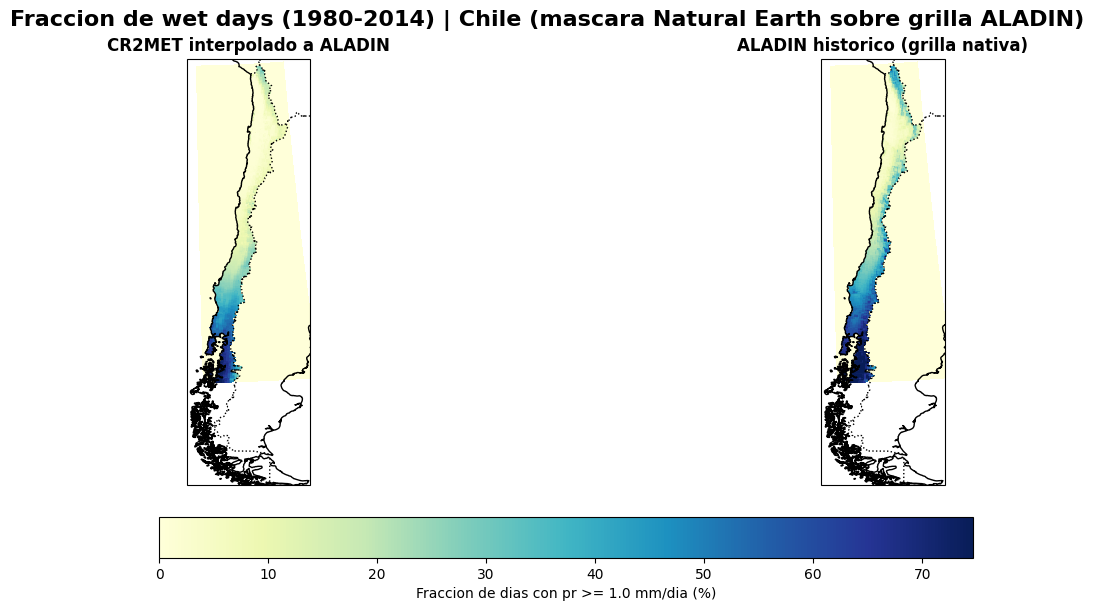

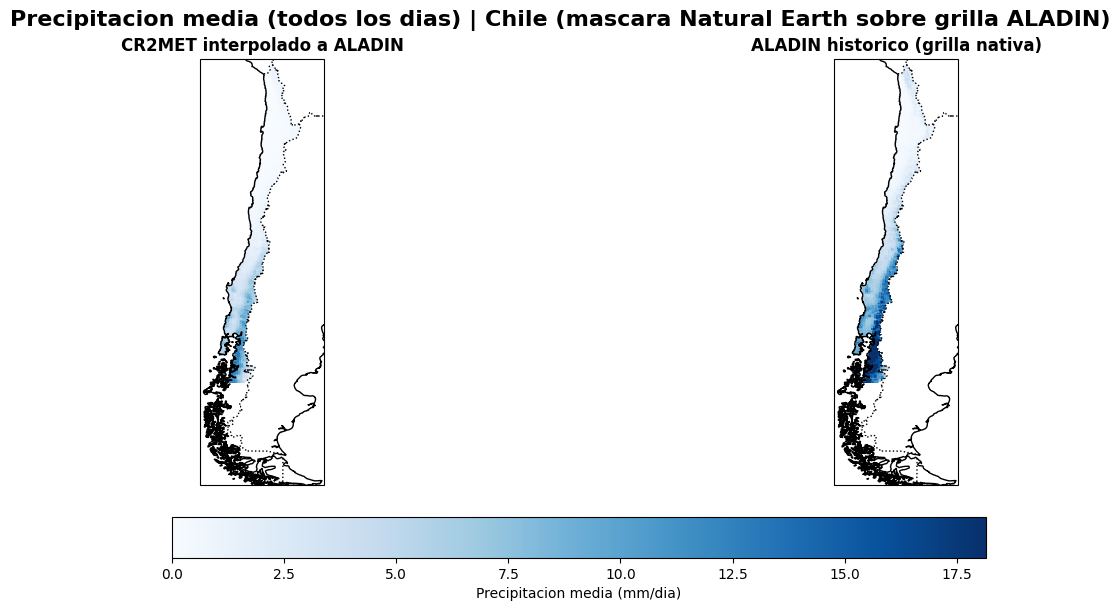

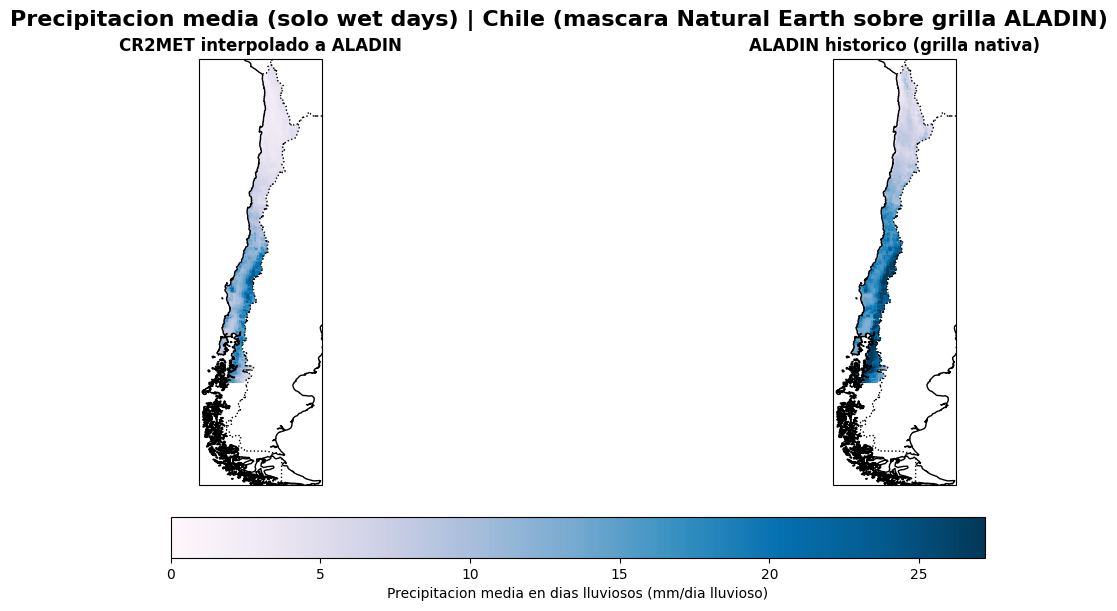

Metricas y mapas: mismo periodo, misma definicion de wet day, misma mascara de Chile y misma grilla ALADIN (CR2MET interpolado).


In [5]:
# =====================================================================
# MAPAS COMPARATIVOS (MISMA GRILLA Y MISMA MASCARA)
# =====================================================================
print('4/4: Graficando mapas comparativos...')

wet_vmax = float(
    np.nanpercentile(
        np.concatenate([
            wet_frac_cr2met.where(chile_mask).values.ravel(),
            wet_frac_aladin.where(chile_mask).values.ravel(),
        ]),
        98,
    )
)
wet_vmax = max(wet_vmax, 10.0)
plot_two_panel_maps(
    wet_frac_cr2met,
    wet_frac_aladin,
    title=f'Fraccion de wet days ({START_DATE[:4]}-{END_DATE[:4]}) | {DOMAIN_LABEL}',
    cbar_label='Fraccion de dias con pr >= 1.0 mm/dia (%)',
    cmap='YlGnBu',
    vmin=0.0,
    vmax=wet_vmax,
)

mean_all_vmax = float(
    np.nanpercentile(
        np.concatenate([
            mean_all_cr2met.where(chile_mask).values.ravel(),
            mean_all_aladin.where(chile_mask).values.ravel(),
        ]),
        98,
    )
)
mean_all_vmax = max(mean_all_vmax, 1.0)
plot_two_panel_maps(
    mean_all_cr2met,
    mean_all_aladin,
    title=f'Precipitacion media (todos los dias) | {DOMAIN_LABEL}',
    cbar_label='Precipitacion media (mm/dia)',
    cmap='Blues',
    vmin=0.0,
    vmax=mean_all_vmax,
)

mean_wet_vmax = float(
    np.nanpercentile(
        np.concatenate([
            mean_wet_cr2met.where(chile_mask).values.ravel(),
            mean_wet_aladin.where(chile_mask).values.ravel(),
        ]),
        98,
    )
)
mean_wet_vmax = max(mean_wet_vmax, 1.0)
plot_two_panel_maps(
    mean_wet_cr2met,
    mean_wet_aladin,
    title=f'Precipitacion media (solo wet days) | {DOMAIN_LABEL}',
    cbar_label='Precipitacion media en dias lluviosos (mm/dia lluvioso)',
    cmap='PuBu',
    vmin=0.0,
    vmax=mean_wet_vmax,
)

print(
    'Metricas y mapas: mismo periodo, misma definicion de wet day, '
    'misma mascara de Chile y misma grilla ALADIN (CR2MET interpolado).'
)
